# Clinical GraphRAG Quick Start

This notebook runs through the Quick Start pipeline (Steps 0–5) from the README.

**Prerequisites:**
- [uv](https://docs.astral.sh/uv/getting-started/installation/) installed
- **API key:** Create `api_keys.json` with your OpenRouter key (see Step 1 below)

**Excluded:** Step 7 (LLM Judge) — optional and costly.

## Setup: Ensure we're in the project root

In [ ]:
import os
from pathlib import Path

# Ensure we're in project root (parent of notebooks/)
cwd = Path.cwd()
if (cwd / "pyproject.toml").exists():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = cwd.parent
    os.chdir(PROJECT_ROOT)

print(f"Project root: {Path.cwd()}")

In [2]:
pass  # Setup complete

## Step 0: Sync dependencies

Run `uv sync` to install project dependencies. (Install uv first: `curl -LsSf https://astral.sh/uv/install.sh | sh`)

In [3]:
!uv sync    # ! Run this cell to install the dependencies (runs in the system shell rather than the notebook kernel)

Resolved 204 packages in 2ms
Audited 116 packages in 2ms


## Step 1: Set your OpenRouter API key

Replace the placeholder below with your key from [OpenRouter](https://openrouter.ai/keys), then run the cell.

In [4]:
import json
from pathlib import Path

OPENROUTER_KEY = "" # ← Replace with your key from https://openrouter.ai/keys
Path("api_keys.json").write_text(json.dumps({"openrouter": OPENROUTER_KEY}, indent=2))

95

## Step 2: KG Extraction

Extract entities and relations from transcripts (single-pass baseline via OpenRouter GLM).

In [5]:
!uv run python -m Clinical_KG_OS_LLM.kg_extraction --output ./my_kg

KG Extraction Pipeline
Method: naive
Model:  glm
Output: my_kg
Processing 2 transcripts
  RES0198... (23n/9e)
  RES0217... (20n/10e)
Done! Success: 2, Failed: 0
Total tokens: 19432
Output: my_kg/


## Step 3: Entity Resolution (Dump Graph)

Merge per-patient KGs into a unified graph. Output: `unified_graph_my_kg.json` when input is `./my_kg`.

In [6]:
!uv run python -m Clinical_KG_OS_LLM.dump_graph --input ./my_kg --output ./my_kg_naive

KG Graph Merger
Input:  my_kg
Output: my_kg_naive/unified_graph_my_kg.json
Loading bge-m3...
Loading weights: 100%|█| 391/391 [00:00<00:00, 13687.09it/s, Materializing param
Loaded 2 sub-KGs: 43 entities, 19 edges
  SYMPTOM: 18 unique names
  DIAGNOSIS: 4 unique names
  TREATMENT: 6 unique names
  PROCEDURE: 5 unique names
  LOCATION: 6 unique names
  MEDICAL_HISTORY: 2 unique names
  LAB_RESULT: 1 unique names

Entity Resolution: 42 -> 41 canonical entities
Saved: my_kg_naive/er_merge_decisions_my_kg.json
Saved: my_kg_naive/unified_graph_my_kg.json

Unified graph: 41 nodes, 19 edges
Done.


## Step 4: GraphRAG QA Pipeline

Answer clinical questions using the unified KG. Use `--questions Q1` for a quick run; omit to run all questions.

In [7]:
!uv run python -m Clinical_KG_OS_LLM.graphrag_qa_pipeline --kg ./my_kg_naive/unified_graph_my_kg.json --questions Q1

=== GraphRAG-QA Pipeline ===
  KG     : my_kg_naive/unified_graph_my_kg.json
  Bundle : src/Clinical_KG_OS_LLM/transcripts
  Output : my_kg_naive/results_unified_graph_my_kg

Loading embedding model (BAAI/bge-m3)...
Loading weights: 100%|█| 391/391 [00:00<00:00, 13252.41it/s, Materializing param

Loading KG (unified_graph_my_kg.json)...
  41 nodes, 19 edges
  Loading cached embeddings from embeddings_cache/unified_graph_my_kg.npz...
  Cache mismatch, recomputing...
  Computing embeddings for 41 nodes...
Generating embeddings: 100%|████████████████████| 41/41 [00:01<00:00, 28.93it/s]
  Cached embeddings to embeddings_cache/unified_graph_my_kg.npz

  RES0198  (1 questions)

  [Q1] What specific nasal symptoms did the patient report, what was the character of t...
    retrieval  0.7s
    generation 55.8s (openrouter)
    preview    Based on the clinical information and transcript provided:

**Specific Nasal Symptoms Reported**
The patient explicitly ...

  Saved → my_kg_naive/results_unif

## Step 5: Quick Quality Check

Compare your KG against the curated baseline. Outputs composite score and report.

In [8]:
!uv run python -m Clinical_KG_OS_LLM.kg_similarity_scorer --student ./my_kg_naive/unified_graph_my_kg.json --baseline ./src/Clinical_KG_OS_LLM/baseline_results/baseline_curated/unified_graph_curated.json

KG Similarity Report
Student KG:   ./my_kg_naive/unified_graph_my_kg.json
Baseline KG:  ./src/Clinical_KG_OS_LLM/baseline_results/baseline_curated/unified_graph_curated.json

  COMPOSITE SCORE: 0.339
  (Correlates r=0.94 with QA performance)

Component Scores:
  Entity F1 (25%):              0.160
  Population Completeness (25%): 0.123
  Relation Completeness (25%):   0.074
  Schema Completeness (25%):     1.000

Detailed Node Overlap:
  Precision: 51.22% (21/41 student nodes matched)
  Recall:    9.50% (21/221 baseline nodes covered)
  F1 Score:  16.03%

Structural Comparison:
  Student:   41 nodes, 19 edges, density 0.46
  Baseline:  222 nodes, 171 edges, density 0.77

Per-Patient Average Coverage: 4.17%

Grade: F (Poor - significant issues)


## Step 6: Visualize the Knowledge Graph

Render your unified KG as a graph (nodes = entities, edges = relations). Use `--res-id` to show one patient's subgraph.

In [9]:
!uv run python -m Clinical_KG_OS_LLM.visualize_kg \
  --kg ./my_kg_naive/unified_graph_my_kg.json \
  --output ./my_kg_naive/kg_graph.png

Saved: my_kg_naive/kg_graph.png


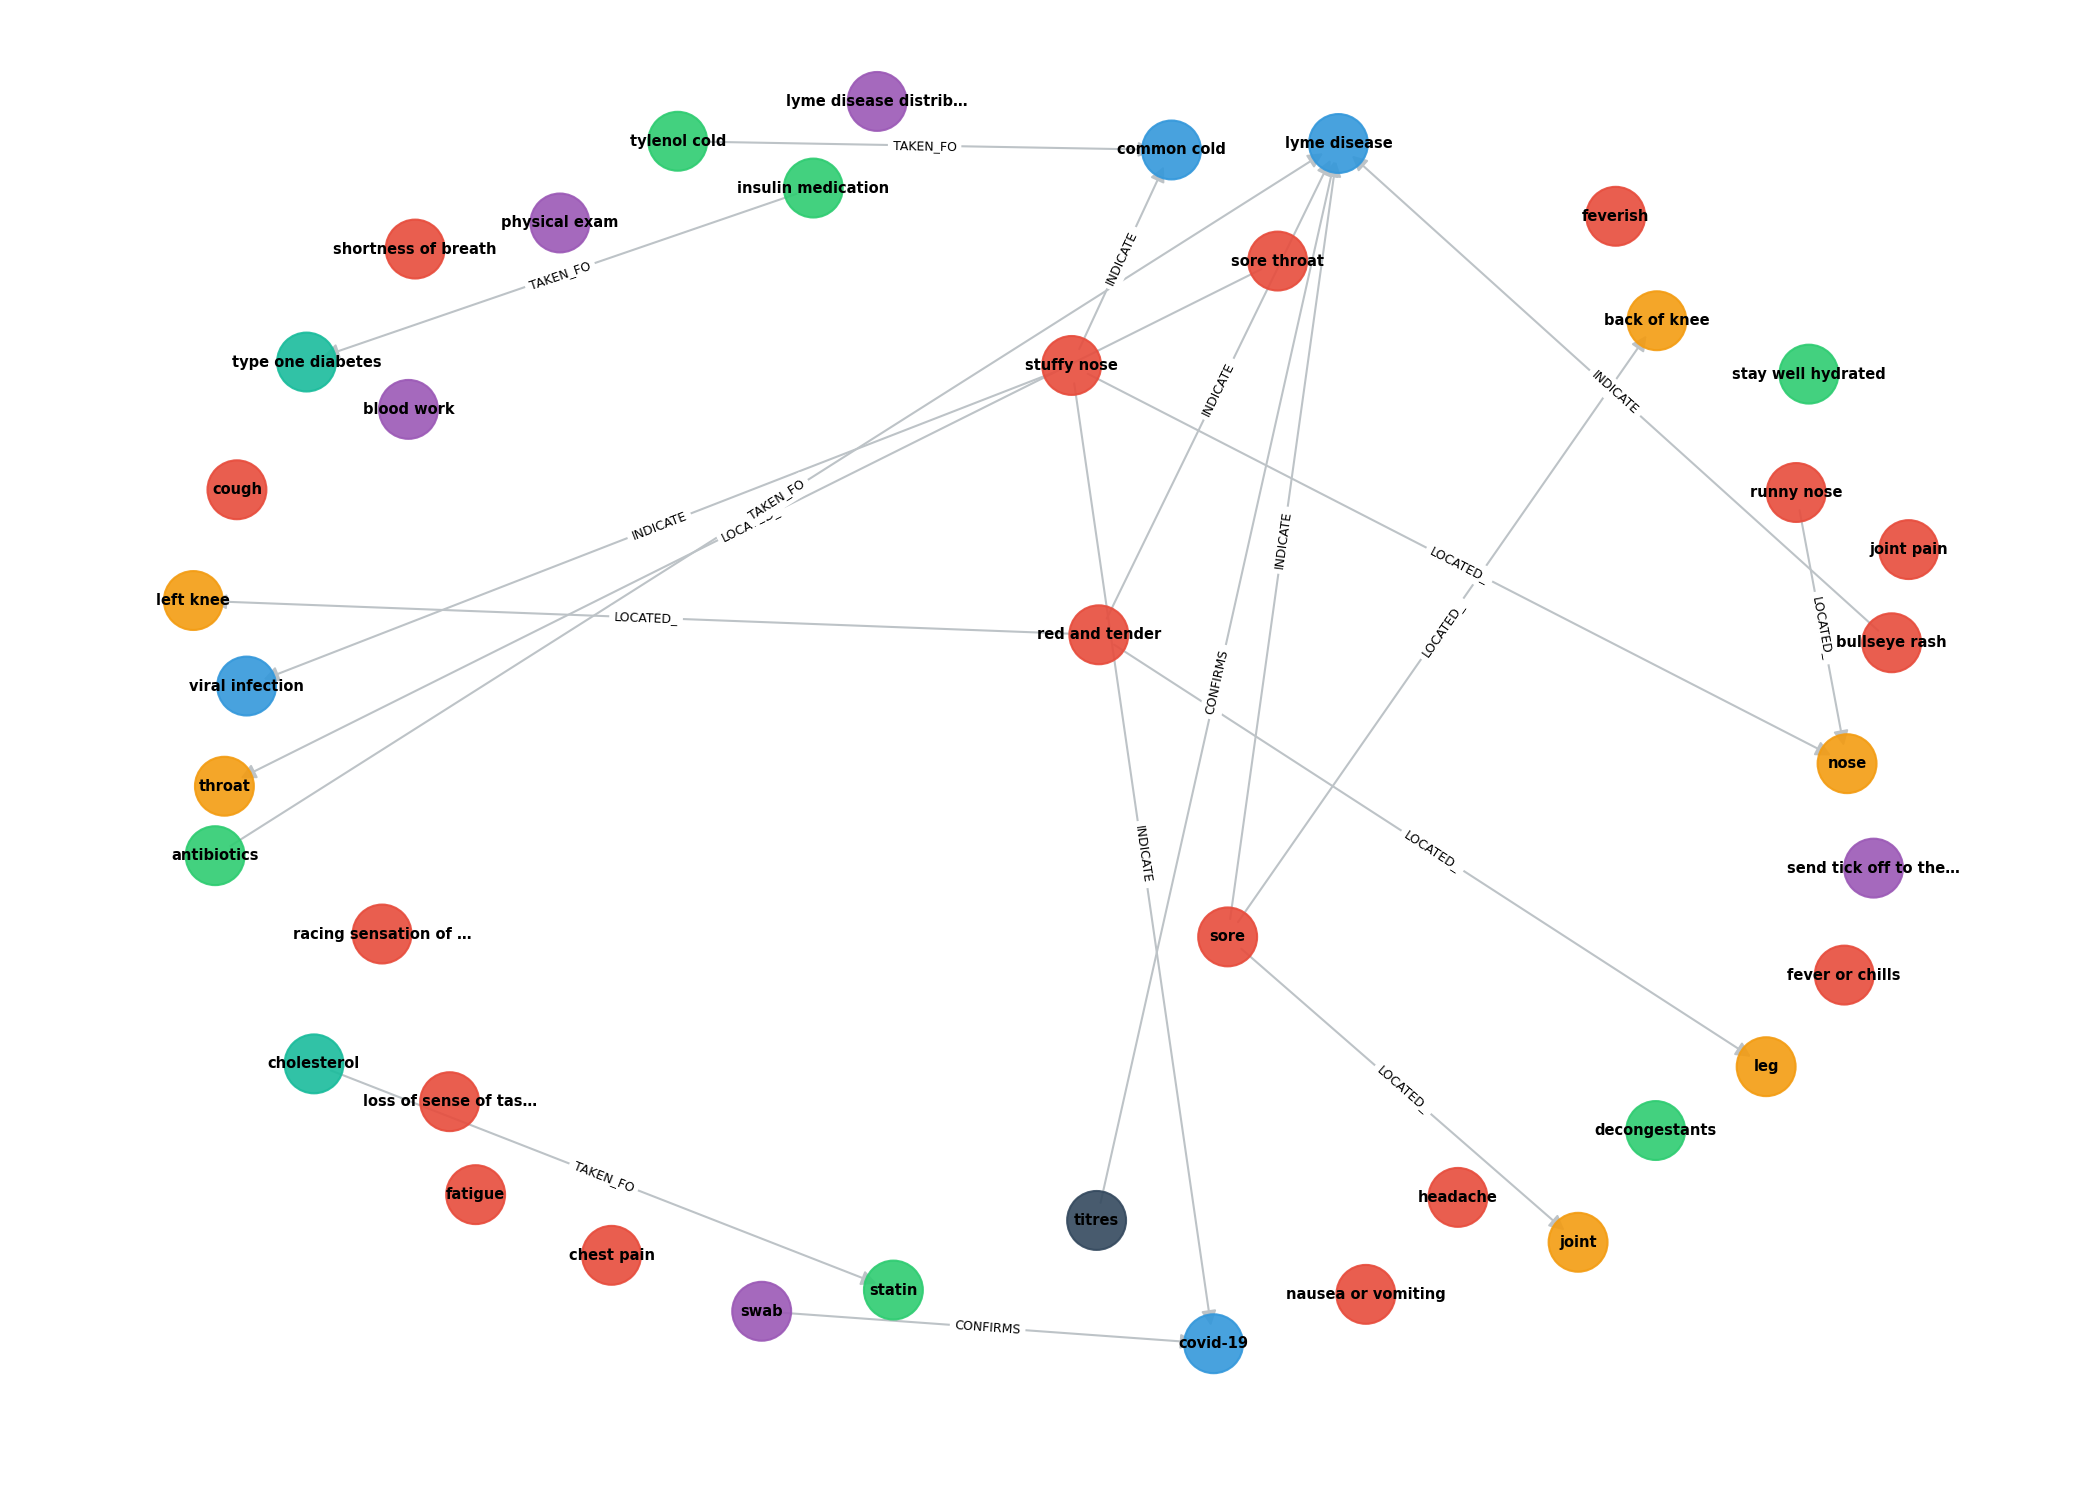

In [10]:
from IPython.display import Image, display
display(Image(filename="./my_kg_naive/kg_graph.png"))

# Check OpenRouter credits [Optional]

In [13]:
os.environ['API_KEY'] = ""  # ← Replace with your key from https://openrouter.ai/keys
!uv run python -m Clinical_KG_OS_LLM.check_openrouter_credits

💳 API Key Credit Balance:
   Key limit:    $1.00
   Key usage:    $0.10
   Remaining:    $0.90


## Done

Pipeline complete. Results:
- **QA answers:** `./my_kg_naive/results_unified_graph_my_kg/`
- **KG graph:** `./my_kg_naive/kg_graph.png`
- **Step 7 (LLM Judge):** Optional, ~$8–10 per run — executed by hackathon organizers only.